In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from itertools import combinations
from scipy.spatial import ConvexHull

In [ ]:
def transform_points(p1, p2):
    x = (p1[0],p2[0])
    y = (p1[1],p2[1])
    return x, y

def median_combinations(median_segments):
    valid_combs = []
    all_combs = list(combinations(median_segments,2))
    for comb in all_combs:
        l1, l2 = comb
        p1, p2 = l1
        if p1 in l2:
            valid_combs.append(comb)
            continue
        if p2 in l2:
            valid_combs.append(comb)
            continue
    return valid_combs

def combination_with_biggest_angle(combs):
    recent_angle = 0
    comb_to_return = None
    picked_counter_angle_to_return = None
    for comb in combs:
        l1, l2 = comb
        angle, picked_counter_angle = angle_between_vectors(l1, l2)
        if angle == None:
            continue
        elif angle > recent_angle:
            recent_angle = angle
            comb_to_return = comb
            picked_counter_angle_to_return = picked_counter_angle
    return comb_to_return, recent_angle, picked_counter_angle_to_return

def comb_to_same_start(comb):
    c1, c2 = comb
    if c1[0] == c2[0]:
        new_comb = comb
    elif c1[0] == c2[1]:
        new_comb = (c1, (c2[1], c2[0]))
    elif c1[1] == c2[0]:
        new_comb = ((c1[1], c1[0]), c2)
    elif c1[1] == c2[1]:
        new_comb = ((c1[1], c1[0]), (c2[1],c2[0]))
    return new_comb

def angle_between_vectors(l1, l2):
    l1, l2 = comb_to_same_start((l1, l2))
    
    p1, p2 = l1
    p3, p4 = l2
    
    v1 = np.array([p2[0]-p1[0], p2[1]-p1[1]])
    v2 = np.array([p4[0]-p3[0], p4[1]-p3[1]])
    
    angle = abs(np.arctan2(v1[1], v1[0]) - np.arctan2(v2[1],  v2[0]))%np.pi
    counter_angle = np.pi - angle
    # if angle < np.pi/2:
    #     res = angle
    #     picked_counter_angle = False
    # else: 
    #     res = counter_angle
    #     picked_counter_angle = True
    res = angle
    if angle < np.pi/2:
        picked_counter_angle = False
    else:
        picked_counter_angle = True
    return res, picked_counter_angle

def orthogonal_points(coords, s=0.5):
    """Given a tuple coords containing two 2-dimensional points and also
    given a positive number s, return two other distinct points such
    that the line segment between each output point and coords[0] is
    orthogonal (perpendicular) to the line segment between coords[0] and
    coords[1] and the distance from each output point to coords[0] is s.
    """
    (point1x, point1y), (point2x, point2y) = coords
    points_vectorx, points_vectory = point2x - point1x, point2y - point1y
    points_vector_length = math.hypot(points_vectorx, points_vectory)
    normalized_x, normalized_y = (points_vectorx * s / points_vector_length,
                                  points_vectory * s / points_vector_length)
    newpoint1x, newpoint1y = point1x + normalized_y, point1y - normalized_x
    newpoint2x, newpoint2y = point1x - normalized_y, point1y + normalized_x
    res = ([newpoint1x, newpoint1y], [newpoint2x, newpoint2y])
    return res

def line_intersection(line1, line2):
    xdiff = (line1[0][0] - line1[1][0], line2[0][0] - line2[1][0])
    ydiff = (line1[0][1] - line1[1][1], line2[0][1] - line2[1][1])

    def det(a, b):
        return a[0] * b[1] - a[1] * b[0]

    div = det(xdiff, ydiff)
    if div == 0:
       raise Exception('lines do not intersect')

    d = (det(*line1), det(*line2))
    x = det(d, xdiff) / div
    y = det(d, ydiff) / div
    return x, y

def circle(center, radius):
    theta = np.linspace(-np.pi, np.pi, 100)
    xc, yc = center
    x = xc + radius * np.cos(theta)
    y = yc + radius * np.sin(theta)
    return x, y

def side_of_line(p, a, b):
    """
    Returns:
        >0  → p is left of the line a→b
        <0  → p is right of the line a→b
         0  → p lies exactly on the line
    """
    res = (b[0] - a[0])*(p[1] - a[1]) - (b[1] - a[1])*(p[0] - a[0])
    return res

def orthogonal_connection_exists(P, A, B):
    """
    A, B, P are 2D points as numpy arrays, e.g. np.array([x, y])
    Returns True if the perpendicular projection of P onto AB
    lies within the segment AB.
    """

    A = np.array(A)
    B = np.array(B)

    AB = B - A
    AP = P - A

    # Squared length of AB
    AB_len2 = np.dot(AB, AB)
    if AB_len2 == 0:
        return False  # A and B are the same point

    # Projection parameter t
    t = np.dot(AP, AB) / AB_len2

    # Check if projection lies on the segment
    return 0 <= t <= 1

def side_of_segment(p, a, b, only_in_bounds=True):
    """
    Classifies point p relative to the directed segment a→b.

    Returns:
        "left"         → p is left of the segment
        "right"        → p is right of the segment
        "on"           → p lies exactly on the segment line
        "out_of_bounds"→ perpendicular projection is not between a and b
    """
    # Vector ab and ap
    AB = (b[0] - a[0], b[1] - a[1])
    AP = (p[0] - a[0], p[1] - a[1])

    if only_in_bounds:
        in_bounds = orthogonal_connection_exists(p, a, b)
        if not in_bounds:
            return "out_of_bounds"

    # Cross product to determine left/right/on
    cross = AB[0]*AP[1] - AB[1]*AP[0]
    
    if cross > 0:
        return "left"
    elif cross < 0:
        return "right"
    else:
        return "on"

def get_median_lines(points, only_in_bounds=True):
    majority = len(points)//2 + 1

    median_lines = []

    point_combs = list(combinations(points,2))
    for pc in point_combs: 
        right_counter = 0
        left_counter = 0
        for p in points:
            if p in pc:
                continue
            s = side_of_segment(p, *pc, only_in_bounds=only_in_bounds)
            if s == "left":
                left_counter += 1
            elif s == "right":
                right_counter += 1
            elif s == "on":
                left_counter += 1
                right_counter += 1
        left_counter += 2
        right_counter += 2
        if left_counter >= majority and right_counter >= majority:
            median_lines.append(pc)
    return median_lines

def circle_line_intersect(circle_center, circle_radius, line):
    # Line direction vector
    h, k = circle_center

    (x1, y1), (x2, y2) = line

    dx = x2 - x1
    dy = y2 - y1

    # Convert to line equation coefficients: Ax + By + C = 0
    A = dy
    B = -dx
    C = dx * y1 - dy * x1

    # Distance from circle center to the line
    d = abs(A*h + B*k + C) / math.sqrt(A*A + B*B)

    if d < circle_radius:
        return True # "The line intersects the circle (two points)."
    elif d == circle_radius:
        return True # "The line is tangent to the circle (one point)."
    else:
        return False # "The line does not intersect the circle."
    
def yolk_1_median(median_lines):
    p1, p2 = median_lines[0]
    x1, y1 = p1
    x2, y2 = p2
    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    yolk_center = (mid_x, mid_y)
    yolk_radius = 0
    return yolk_center, yolk_radius

def yolk_2_median(median_lines):
    l1, l2 = median_lines
    yolk_center = line_intersection(l1, l2)
    yolk_radius = 0
    return yolk_center, yolk_radius

def yolk_greater_2_median(median_lines, points, accuracy=0.1):
    mcombs = median_combinations(median_lines)

    # new_lines = []
    # all_mcombs = list(combinations(median_lines,2))
    # for l1, l2 in all_mcombs:
    #     try:
    #         comb_to_same_start((l1, l2))
    #     except:
    #         intersect = line_intersection(l1,l2)
    #         new_lines.append((intersect, l1[0]))
    #         new_lines.append((intersect, l2[0]))
    #         new_lines.append((intersect, l1[1]))
    #         new_lines.append((intersect, l2[1]))
    # mcombs = list(combinations(new_lines, 2)) + mcombs

    # 
    all_median_lines = get_median_lines(points, only_in_bounds=False)

    # # Es gibt den seltenen Fall, dass sich keine Median-Kombination ergeben kann. Dann überkreuzen sich die Median-Linien nicht in ihren Start- oder Endpunkten.
    # if len(mcombs) == 0:
    #     intersections = []
    #     mcombs = list(combinations(median_lines,2))
    #     for comb in mcombs:
    #         intersections.append(line_intersection(*comb))
    #     if len(intersections) == 1:
    #         yolk_center, yolk_radius = intersections[0], 0
    #         return yolk_center, yolk_radius
    #     if len(intersections) == 2:
    #         yolk_center, yolk_radius = yolk_1_median([(intersections[0],intersections[1])])
    #         return yolk_center, yolk_radius


    comb, angle, picked_counter_angle = combination_with_biggest_angle(mcombs)
    comb = comb_to_same_start(comb)

    c1, c2 = comb
    c1 = np.array(c1) 
    c2 = np.array(c2)
    r1 = np.array([c1[1]-c1[0],c1[1]-c1[0]]) 
    r2 = np.array([c2[1]-c2[0],c2[1]-c2[0]])

    angle_vector = 1/2 * (r1/np.linalg.norm(r1) + r2/np.linalg.norm(r2))
    angle_vector = angle_vector/np.linalg.norm(angle_vector)

    points_comb = list(combinations(np.array(points),2))
    dists = [np.linalg.norm(pc[0]-pc[1]) for pc in points_comb]
    max_dist = max(dists)
    
    dists_to_check = np.arange(accuracy, max_dist, accuracy)

    median_lines_to_cross = [ml for ml in all_median_lines if ml not in comb]
    # median_lines_to_cross = [ml for ml in median_lines if list(dict(comb).keys())[0] not in ml]

    yolk_center = []
    yolk_radius = 0
    for n, distance in enumerate(dists_to_check):
        circle_center = (c1[0] + distance * angle_vector)[0]
        if not picked_counter_angle:
            circle_radius = np.sin(angle/2) * distance * 1/np.sqrt(2) # sin
        else:
            circle_radius = np.cos(angle/2) * distance * 1/np.sqrt(2) # cos
        intersections_check = [circle_line_intersect(circle_center, circle_radius, ml) for ml in median_lines_to_cross]
        if sum(intersections_check) == len(median_lines_to_cross):
            yolk_center = circle_center
            yolk_radius = circle_radius
            break

        if n == len(dists_to_check)//4:
            fig, ax = plt.subplots()
            median_color = "black"
            yolk_color = "red"
            for p in points:
                ax.plot(p[0],p[1], color="black", marker="X")
                ax.annotate(str(p), p)
            for n, m in enumerate(all_median_lines):
                x, y = transform_points(*m)
                if n == len(all_median_lines)-1:
                    ax.plot(x, y, color=median_color, label="Median Lines")
                else:
                    ax.plot(x, y, color=median_color)

            if circle_radius > 0:
                x, y = circle(circle_center, circle_radius)
                ax.plot(x,y, label="Yolk", color=yolk_color, linestyle="dashed")

            ax.plot(circle_center[0], circle_center[1], "^", color=yolk_color, label="Yolk Center")

            ax.legend(loc="best")
            ax.set_aspect("equal")
    return yolk_center, yolk_radius

def yolk_greater_2_median_alternative(median_lines, points, accuracy=0.1, start_yolk_radius=100000, start_yolk_center=[]):
    # Check if all Median line share a point
    potential_common = median_lines[0][0]
    potential_common_sum = sum([True for l in median_lines if potential_common in l])
    if potential_common_sum == len(median_lines):
        yolk_center, yolk_radius = potential_common, 0
        return yolk_center, yolk_radius
    else:
        potential_common = median_lines[0][1]
        potential_common_sum = sum([True for l in median_lines if potential_common in l])
        if potential_common_sum == len(median_lines):
            yolk_center, yolk_radius = potential_common, 0
            return yolk_center, yolk_radius

    mcombs = median_combinations(median_lines)

    if len(mcombs) == 0:
        new_lines = []
        all_mcombs = list(combinations(median_lines,2))
        for l1, l2 in all_mcombs:
            try:
                comb_to_same_start((l1, l2))
            except:
                intersect = line_intersection(l1,l2)
                new_lines.append((intersect, l1[0]))
                new_lines.append((intersect, l2[0]))
                new_lines.append((intersect, l1[1]))
                new_lines.append((intersect, l2[1]))
        mcombs = list(combinations(new_lines, 2)) + mcombs

    points_comb = list(combinations(np.array(points),2))
    dists = [np.linalg.norm(pc[0]-pc[1]) for pc in points_comb]
    max_dist = max(dists)
    dists_to_check = np.arange(accuracy, max_dist, accuracy)

    yolk_radius = start_yolk_radius
    yolk_center = start_yolk_center

    for comb in mcombs:
        try:
            comb = comb_to_same_start(comb)
        except:
            continue
        angle, picked_counter_angle = angle_between_vectors(*comb)

        c1, c2 = comb
        c1 = np.array(c1) 
        c2 = np.array(c2)
        r1 = np.array([c1[1]-c1[0],c1[1]-c1[0]]) 
        r2 = np.array([c2[1]-c2[0],c2[1]-c2[0]])

        angle_vector = 1/2 * (r1/np.linalg.norm(r1) + r2/np.linalg.norm(r2))
        angle_vector = angle_vector/np.linalg.norm(angle_vector)
        
        median_lines_to_cross = [ml for ml in median_lines if ml not in comb]

        for n, distance in enumerate(dists_to_check):
            circle_center = (c1[0] + distance * angle_vector)[0]
            if not picked_counter_angle:
                circle_radius = np.sin(angle/2) * distance * 1/np.sqrt(2) # sin
            else:
                circle_radius = np.cos(angle/2) * distance * 1/np.sqrt(2) # cos
            intersections_check = [circle_line_intersect(circle_center, circle_radius, ml) for ml in median_lines_to_cross]
            if sum(intersections_check) == len(median_lines_to_cross):
                if circle_radius < yolk_radius:
                    yolk_radius = circle_radius
                    yolk_center = circle_center     
    return yolk_center, yolk_radius

def calculate_yolk(points, accuracy=0.1):
    points = list(dict.fromkeys(points)) # delete duplicate points    
    
    if len(points) == 1:
        yolk_center = points[0]
        yolk_radius = 0
        return yolk_center, yolk_radius
    
    ### Check for 1D
    x = [p[0] for p in points]
    y = [p[1] for p in points]
    if len(set(x)) <= 1:
        yolk_center = (x[0], np.mean(y))
        yolk_radius = 0
        return yolk_center, yolk_radius
    if len(set(y)) <= 1:
        yolk_center = (np.mean(x), y[0])
        yolk_radius = 0
        return yolk_center, yolk_radius

    median_lines = get_median_lines(points)
    
    if len(median_lines) == 0:
        median_lines = get_median_lines(points, only_in_bounds=False)
    if len(median_lines) == 1 and len(points)>=4:
        median_lines = get_median_lines(points, only_in_bounds=False)
    if len(median_lines) == 2 and len(points)>=5:
        median_lines = get_median_lines(points, only_in_bounds=False)

    if len(median_lines) == 1:
        yolk_center, yolk_radius = yolk_1_median(median_lines)
    elif len(median_lines) == 2:
        yolk_center, yolk_radius = yolk_2_median(median_lines)
    elif len(median_lines) > 2:
        median_lines = get_median_lines(points, only_in_bounds=False)
        yolk_center, yolk_radius = yolk_greater_2_median_alternative(median_lines, points, accuracy=accuracy)
    else:
        yolk_center, yolk_radius = [], 0

    return yolk_center, yolk_radius

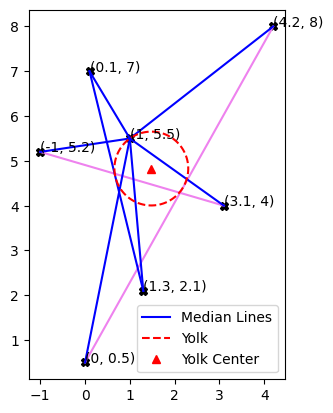

In [229]:
points = [(0,0.5),(1.3,2.1),(-1,5.2),(1,5.5),(3.1,4),(0.1,7),(4.2,8)]

yolk_center, yolk_radius = calculate_yolk(points, accuracy=0.001)

plot = True
colorblind = False
if plot:
    if colorblind:
        median_color = "black"
        segment_color = "black"
        yolk_color = "black"
    else:
        median_color = "blue"
        segment_color = "violet"
        yolk_color = "red"

    median_segments = get_median_lines(points)
    median_lines = get_median_lines(points, only_in_bounds=False)
    median_lines = [ml for ml in median_lines if ml not in median_segments]

    fig, ax = plt.subplots()

    for p in points:
        ax.plot(p[0],p[1], color="black", marker="X")
        ax.annotate(str(p), p)

    for n, m in enumerate(median_segments):
        x, y = transform_points(*m)
        if n == len(median_lines)-1:
            ax.plot(x, y, color=segment_color, label="Median Lines")
        else:
            ax.plot(x, y, color=segment_color)
    
    for n, m in enumerate(median_lines):
        x, y = transform_points(*m)
        if n == len(median_lines)-1:
            ax.plot(x, y, color=median_color, label="Median Lines")
        else:
            ax.plot(x, y, color=median_color)

    if yolk_radius != 0:
        x, y = circle(yolk_center, yolk_radius)
        ax.plot(x,y, label="Yolk", color=yolk_color, linestyle="dashed")

    if len(yolk_center) != 0:
        ax.plot(yolk_center[0], yolk_center[1], "^", color=yolk_color, label="Yolk Center")

    ax.legend(loc="best")
    ax.set_aspect("equal")
    plt.show()

### Data

In [4]:
def choose_cases(dataframe,column_name,cases):
    snippet = dataframe.loc[dataframe[column_name].isin(cases)]
    
    not_found = np.array([])
    for i in cases:
        if i not in np.array(dataframe[column_name]):
            not_found = np.append(not_found,i)
    not_found = np.sort(not_found)
    if len(not_found) == 0:
        print('every case found')
    else:
        print('cases not found:', not_found)
    return snippet

def find_columns_of_values(dataframe,*values):
    correct_columns = np.array([])
    columns = dataframe.columns
    for val in values:
        val_check = 0
        argument_array = np.array([])
        for c in columns:
            column = np.array(dataframe[c])
            if val in column:
                val_check += 1
                correct_columns = np.append(correct_columns,c)
                argument_array = np.append(argument_array, c)
            elif val_check > 1 and c == columns[-1]:
                print(f'Caution: Argument {val} found in several columns: ', argument_array)
            elif val_check == 0 and c == columns[-1]:
                print(f'Caution: Argument {val} not found in data')
            else:
                continue
    return correct_columns

def group_it(dataframe,arguments,columns,*column_names):
    if len(arguments) == 0:
        snippet = dataframe
    elif len(column_names) != 0:
        data_copy = dataframe.copy()
        for c, arg in zip(column_names,arguments):
            groups = data_copy.groupby(c)
            arg_type = type(arg)
            column_as_array = np.array(data_copy[c]).astype(arg_type).flatten()
            if arg in column_as_array:
                snippet = groups.get_group(arg)
                data_copy = snippet
            else:
                print(f'Caution: Argument {arg} not found in column {c}')
                snip = []
                return snip
    else:
        correct_columns = find_columns_of_values(dataframe,*arguments)
        if len(correct_columns) == 0:
            snip = []
            return snip
        data_copy = dataframe.copy()
        for c, arg in zip(correct_columns,arguments):
            groups = data_copy.groupby(c)
            snippet = groups.get_group(arg)
            data_copy = snippet

    if len(columns) == 0:
        snip = snippet
    else:
        snip = snippet.loc[:,[*columns]]

    return snip

In [5]:
manifesto_path = 'data/manifesto/MPDataset_MPDS2025a_stata14.dta'
manifesto = pd.read_stata(manifesto_path,convert_categoricals=False, convert_missing=False)

paged_path = 'data/paged/PAGED-basic.csv'
paged = pd.read_csv(paged_path)

paged_party_path = 'data/paged/REPDEM-Basic-party-dataset.csv'
paged_party = pd.read_csv(paged_party_path)

cases = ["Austria", "Belgium", "Denmark", "Finland", "France", "Germany", "Greece", "Iceland", "Ireland", "Italy", "Luxembourg", "Netherlands", "Norway", "Portugal", "Spain", "Sweden", "Switzerland", "United Kingdom"]

manifesto_case_selection = choose_cases(manifesto, "countryname", cases=cases)
paged_case_selection = choose_cases(paged, "country_name", cases=cases)

state_variables = ["per401", "per402", "per407", "per410", "per414", "per505", "per507", "per702"]
market_variables = ["per403", "per404", "per405", "per406", "per409", "per412", "per413", "per415", "per504", "per506", "per701"]

progressive_variables = ["per601", "per603", "per605", "per608", "per704"]
conservative_variables = ["per201", "per202", "per503", "per602", "per604" , "per607"]

every case found
cases not found: ['Switzerland']


In [9]:
parliament_bib = {}

for index, row in paged_case_selection.iterrows():
    country = row.country_name
    election_date = pd.to_datetime(row.elecdate)

    args = [country, election_date]
    cols = []
    column_names = ["countryname", "edate"]
    manifesto_country_election = group_it(manifesto_case_selection, args, cols, *column_names)

    try:
        member_manifesto_id = [party for party, seatshare in zip(manifesto_country_election.party, manifesto_country_election.absseat) if seatshare > 0]
        member_names = [party for party, seatshare in zip(manifesto_country_election.partyabbrev, manifesto_country_election.absseat) if seatshare > 0]
    except:
        member_manifesto_id = []
        member_names = []

    cabinet_name = row.cab_name
    try:
        cabinet_member = row.cab_composition1.split(",")
        cabinet_member_paged_id = [int(cmid) for cmid in row.cab_composition2.split(",")]
    except AttributeError:
        cabinet_member = []
        cabinet_member_paged_id = []
            
    cabinet_member_manifesto_id = []
    for pid in cabinet_member_paged_id:
        mid = paged_party[paged_party.party_id == pid].manifesto_id.dropna().unique()
        if len(mid) == 1:
            mid = mid[0]
            cabinet_member_manifesto_id.append(mid)
        # If there is no Manifesto ID matching the PAGED ID, -1 is appended.
        elif len(mid) > 1:
            print(f"PAGED ID {pid} has ambigous Manifesto ID: {mid}. Searching for year specific Manifesto ID...")
            mid_found = False
            for id_ in mid:
                if len(manifesto_country_election) != 0:
                    if id_ in manifesto_country_election.party:
                        cabinet_member_manifesto_id.append(id_)
                        mid_found = True
                        print(f"Manifesto ID found.")
                        break
            if not mid_found:
                print(f"Manifesto ID not found.")
                cabinet_member_manifesto_id.append(-1)
        else:
            print(f"PAGED ID {pid} has no Manifesto ID")
            cabinet_member_manifesto_id.append(-1)
    
    if len(manifesto_country_election) == 0:
        cabinet_eco = []
        cabinet_soc = []
        parliament_eco = []
        parliament_soc = []
    else:
        eco = manifesto_country_election[state_variables].sum(axis=1) - manifesto_country_election[market_variables].sum(axis=1)
        eco.index = manifesto_country_election.party
        soc = manifesto_country_election[progressive_variables].sum(axis=1) - manifesto_country_election[conservative_variables].sum(axis=1)
        soc.index = manifesto_country_election.party

        eco = pd.concat([eco, pd.Series({-1:None})])
        soc = pd.concat([soc, pd.Series({-1:None})])
        cabinet_eco = [eco[mid] if mid in eco.index else eco[-1] for mid in cabinet_member_manifesto_id]
        cabinet_soc = [soc[mid] if mid in soc.index else soc[-1] for mid in cabinet_member_manifesto_id]
        parliament_eco = [eco[mid] if mid in eco.index else eco[-1] for mid in member_manifesto_id]
        parliament_soc = [soc[mid] if mid in soc.index else soc[-1] for mid in member_manifesto_id]

    parliament_bib[index] = {
        "country": country,
        "election_date": election_date,
        "member":{
            "name": member_names,
            "manifesto_id": member_manifesto_id,
            "stance_eco": parliament_eco,
            "stance_soc": parliament_soc
        },
        "cabinet": {
            "name": cabinet_name,
            "member": cabinet_member,
            "paged_id": cabinet_member_paged_id,
            "manifesto_id": cabinet_member_manifesto_id,
            "stance_eco": cabinet_eco,
            "stance_soc": cabinet_soc,
        }
        }

Caution: Argument 1945-11-25 00:00:00 not found in column edate
PAGED ID 10001 has no Manifesto ID
Caution: Argument 1945-11-25 00:00:00 not found in column edate
PAGED ID 20001 has no Manifesto ID
PAGED ID 20001 has no Manifesto ID
Caution: Argument 1949-06-26 00:00:00 not found in column edate
PAGED ID 20017 has ambigous Manifesto ID: [21422. 21423. 21425. 21426.]. Searching for year specific Manifesto ID...
Manifesto ID not found.
PAGED ID 20017 has ambigous Manifesto ID: [21422. 21423. 21425. 21426.]. Searching for year specific Manifesto ID...
Manifesto ID not found.
PAGED ID 20017 has ambigous Manifesto ID: [21422. 21423. 21425. 21426.]. Searching for year specific Manifesto ID...
Manifesto ID not found.
PAGED ID 20017 has ambigous Manifesto ID: [21422. 21423. 21425. 21426.]. Searching for year specific Manifesto ID...
Manifesto ID not found.
PAGED ID 20013 has ambigous Manifesto ID: [21913. 21915.]. Searching for year specific Manifesto ID...
Manifesto ID not found.
PAGED ID 200

In [14]:
keys_to_delete = []

for key in parliament_bib.keys():
    eco = parliament_bib[key]["member"]["stance_eco"]
    if len(eco) == 0:
        keys_to_delete.append(key)
        continue
    if pd.isna(eco).any():
        keys_to_delete.append(key)

new_parliament_bib = {k: v for k, v in parliament_bib.items() if k not in keys_to_delete}

2


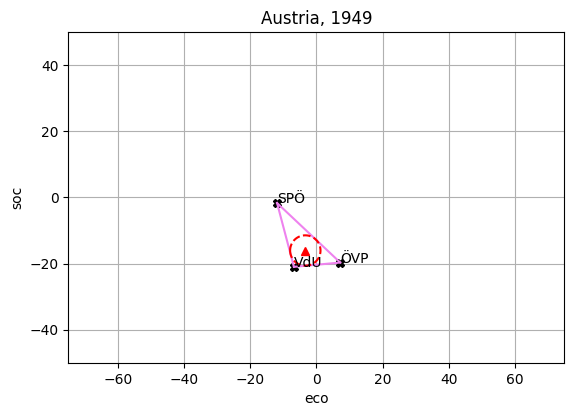

3


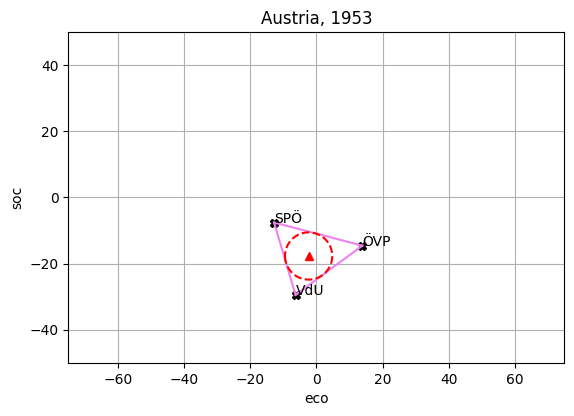

4


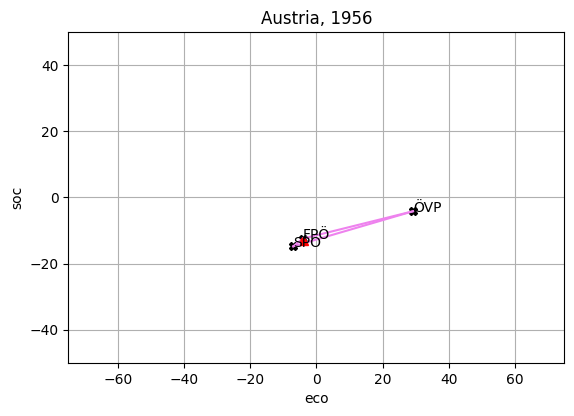

5


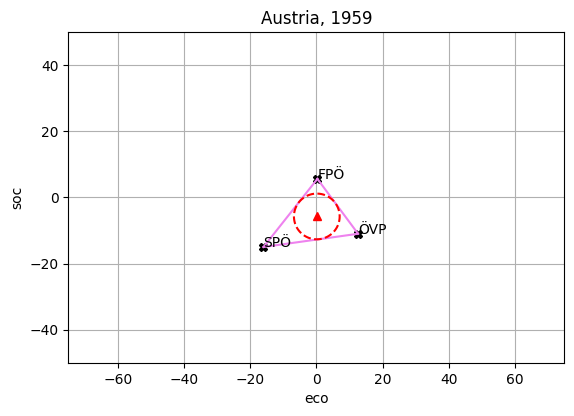

6


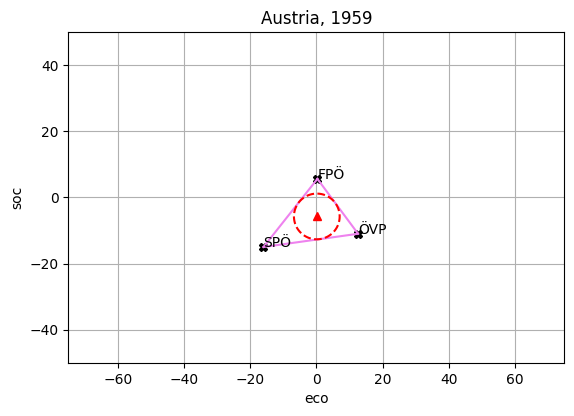

7


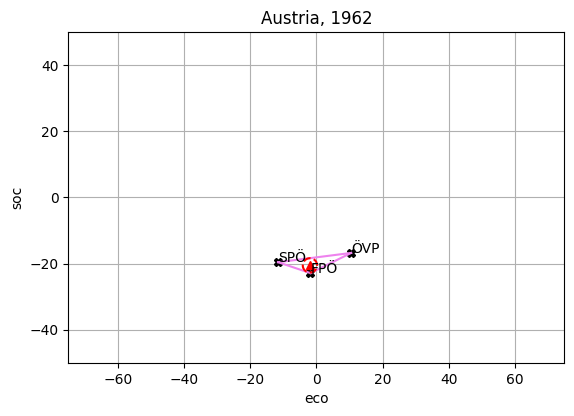

8


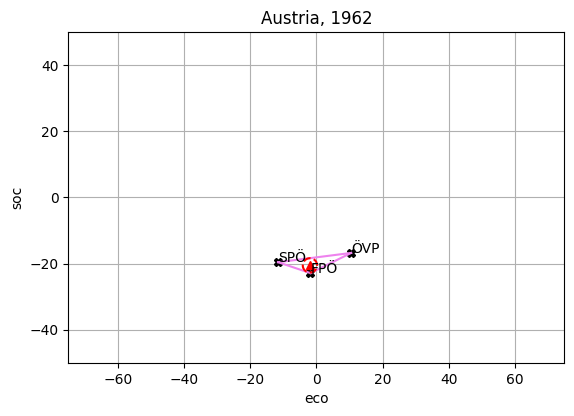

9


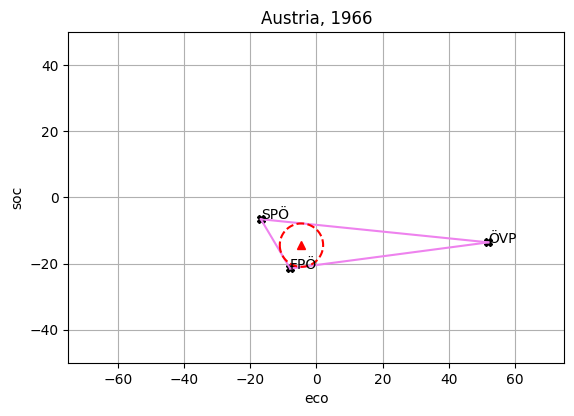

10


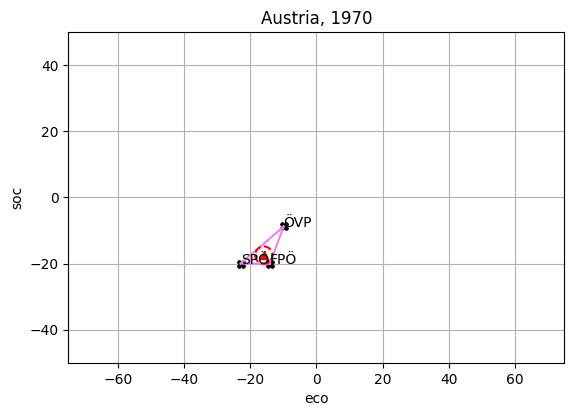

11


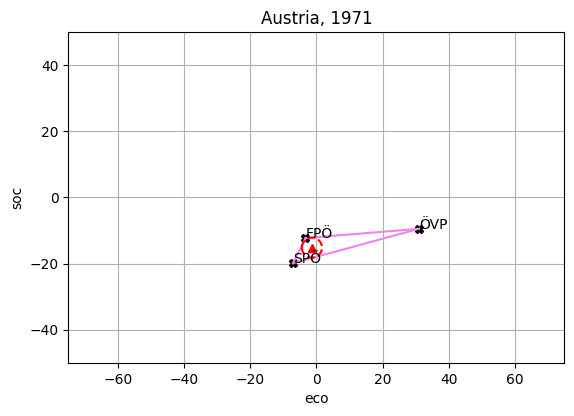

12


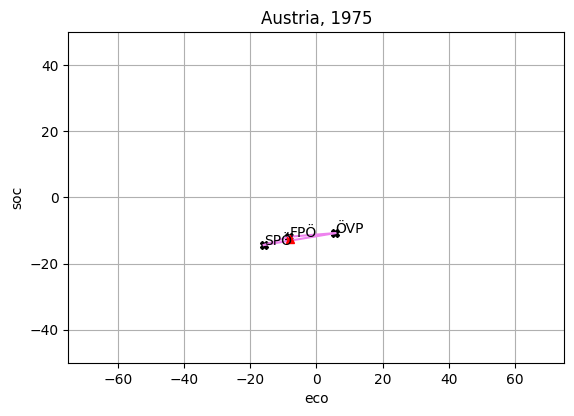

13


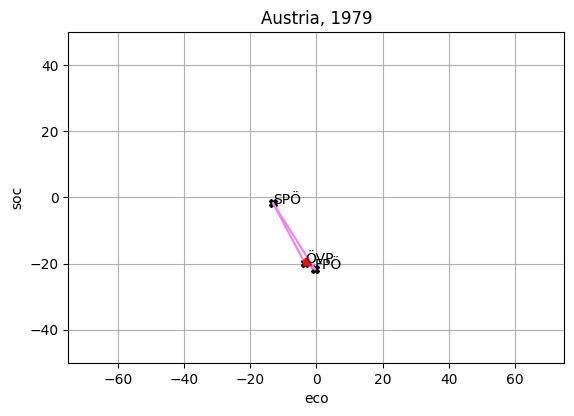

14


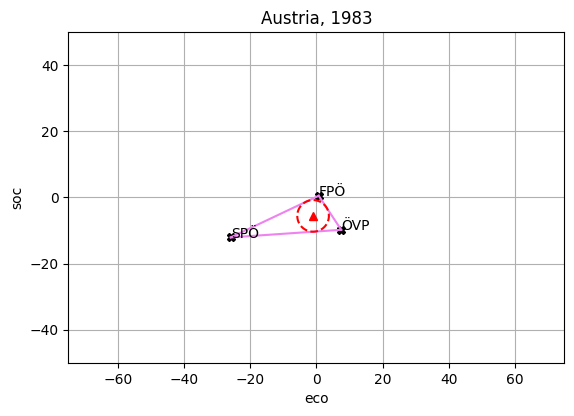

15


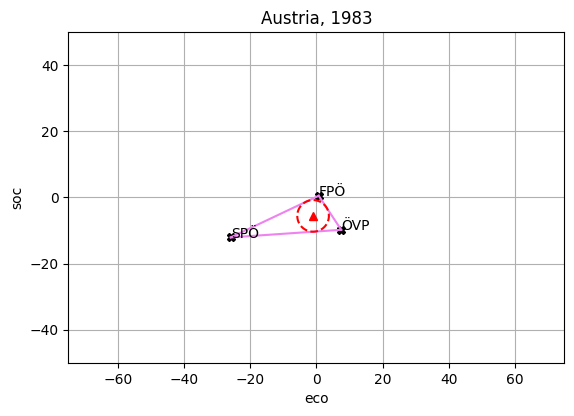

16


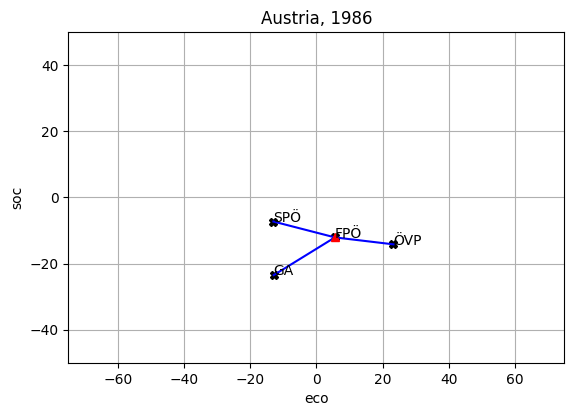

17


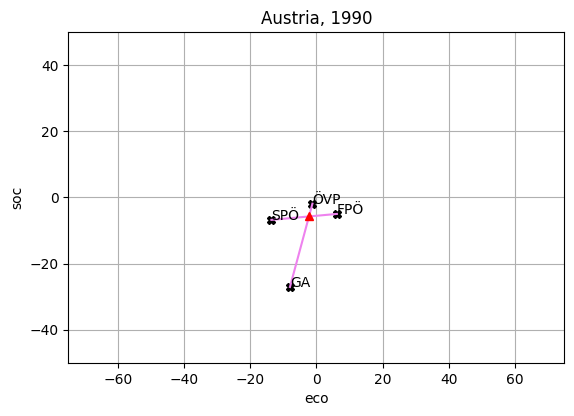

18


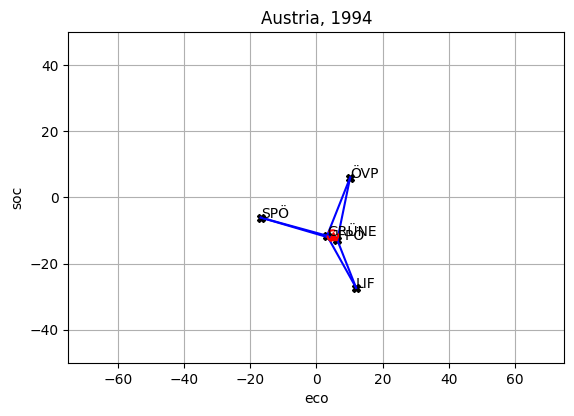

19


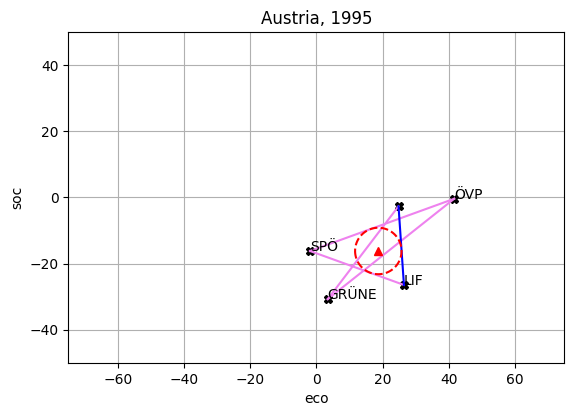

20


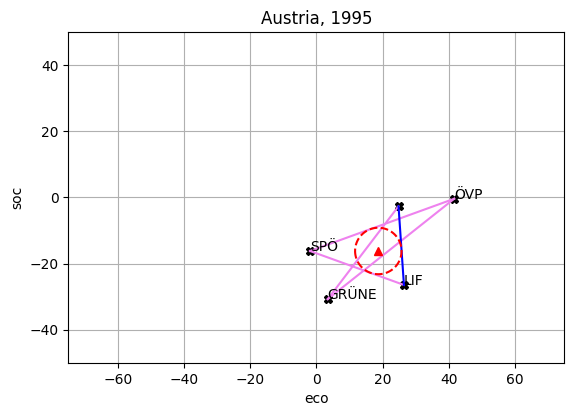

21


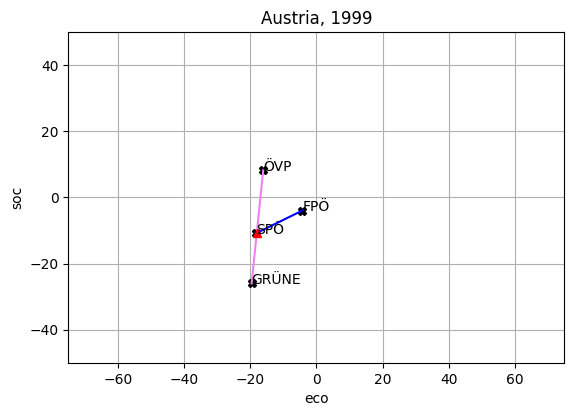

22


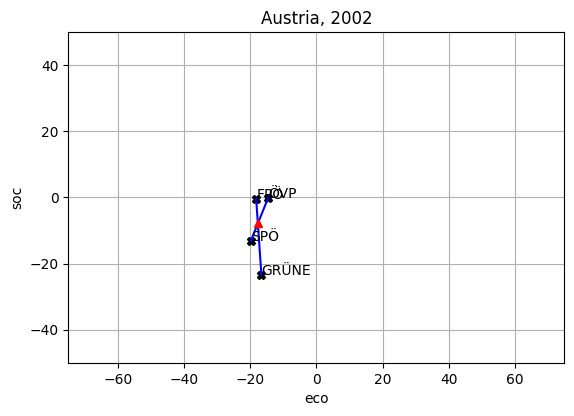

23


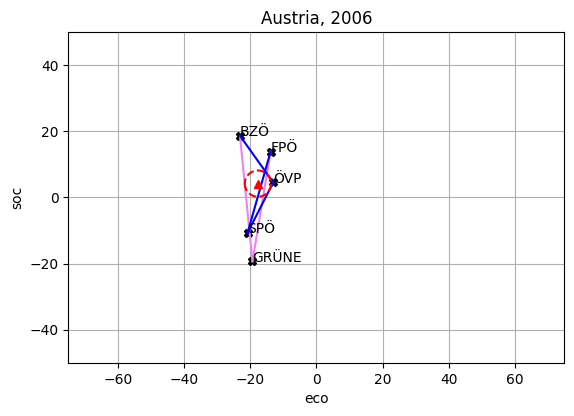

24


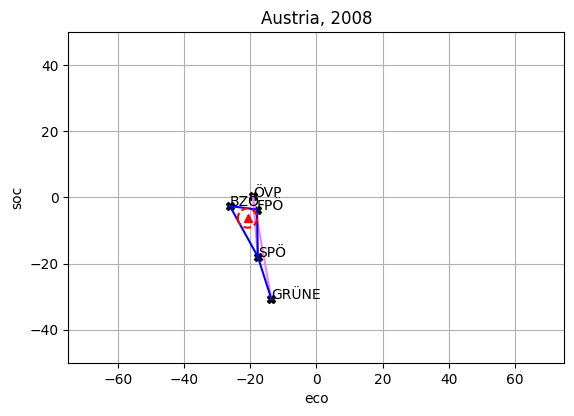

25


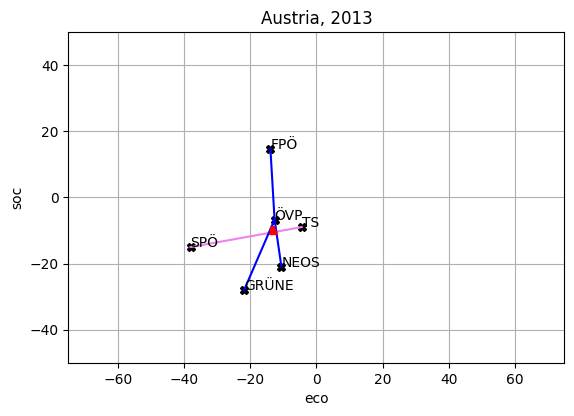

26


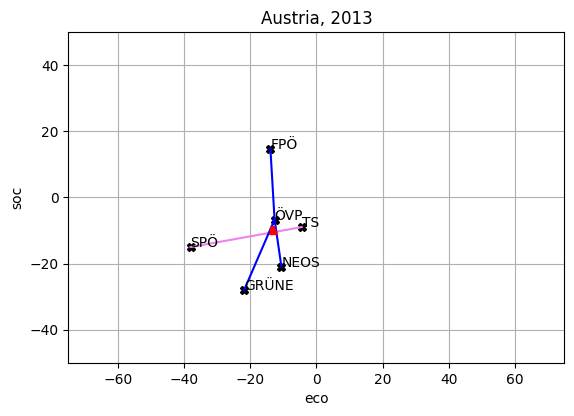

27


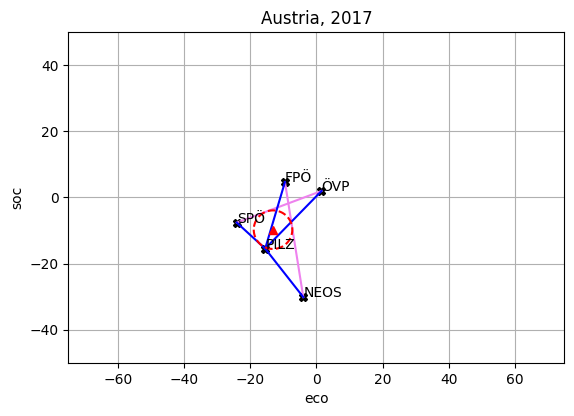

28


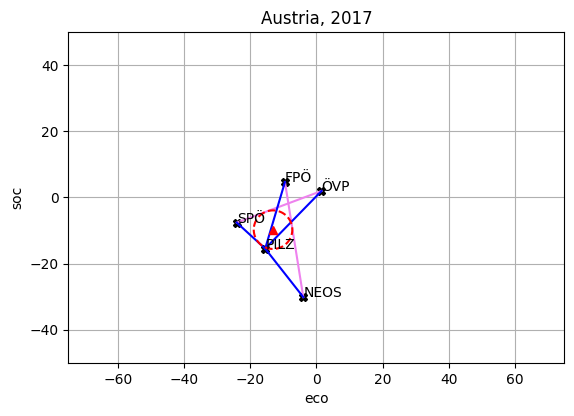

29


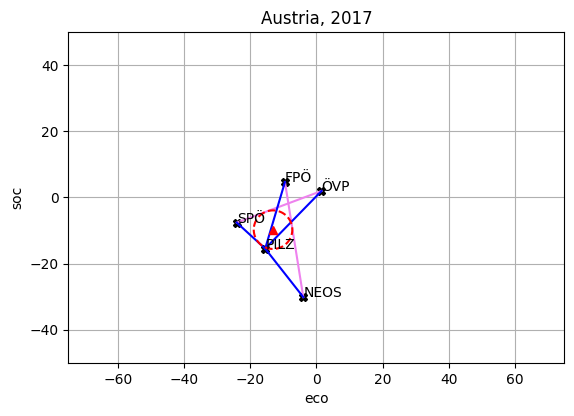

30


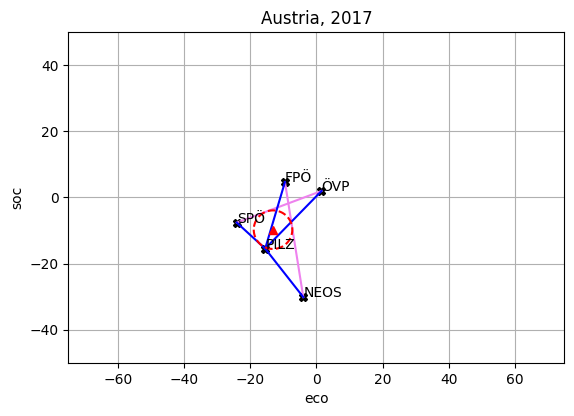

31


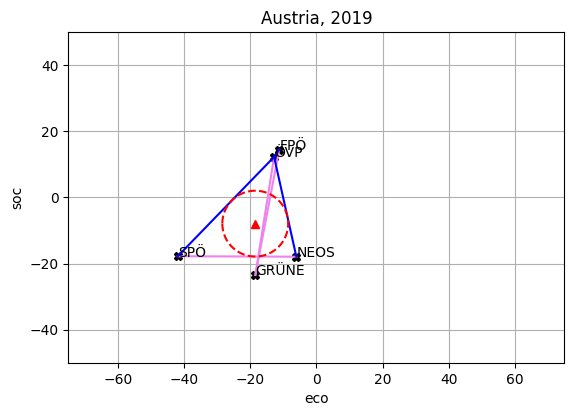

32


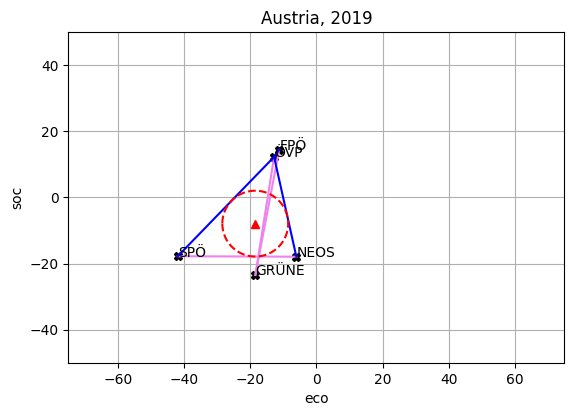

33


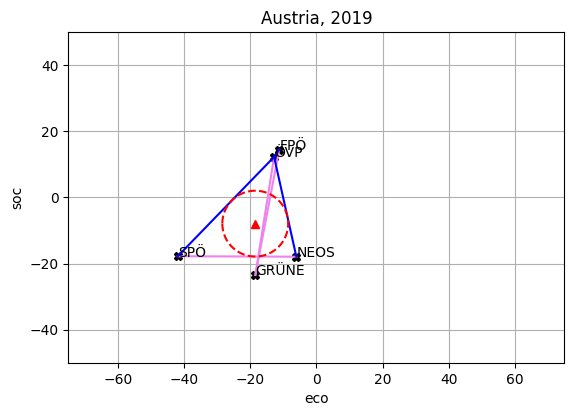

34


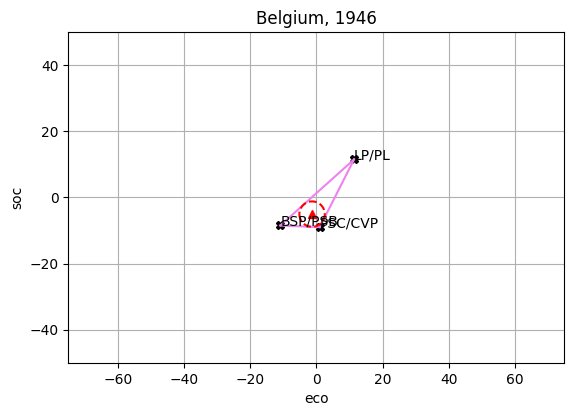

35


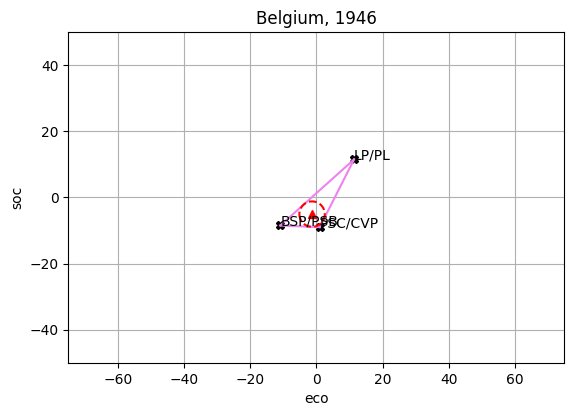

36


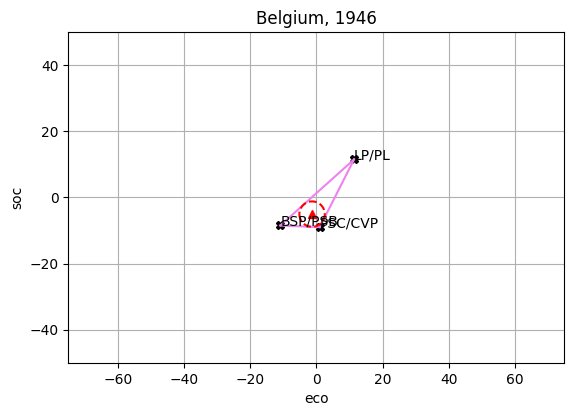

37


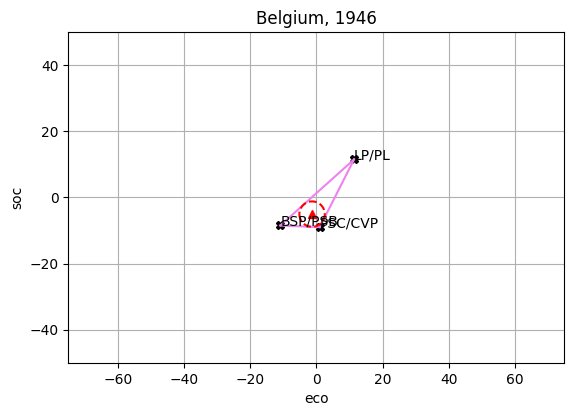

39


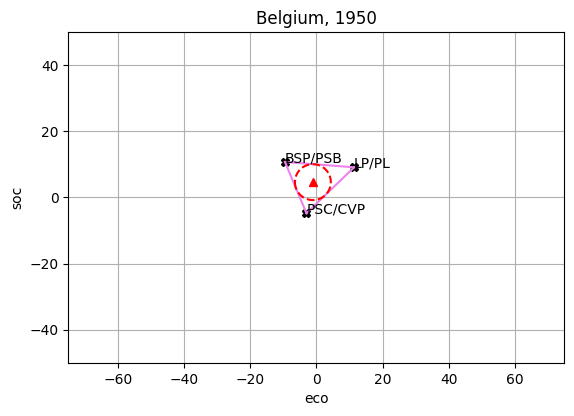

40


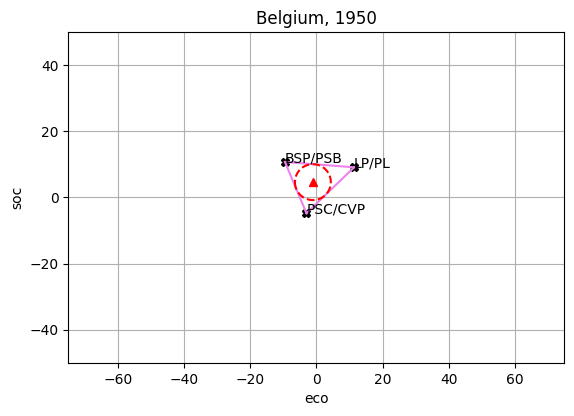

41


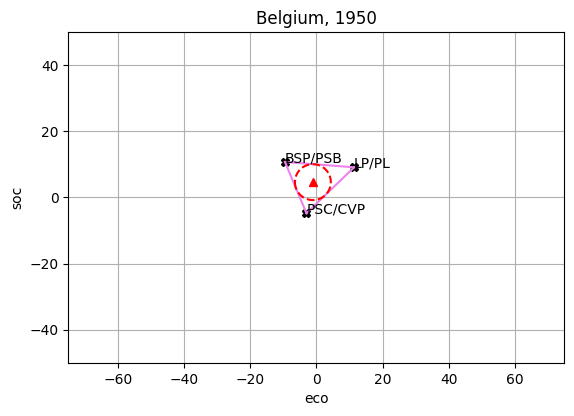

42


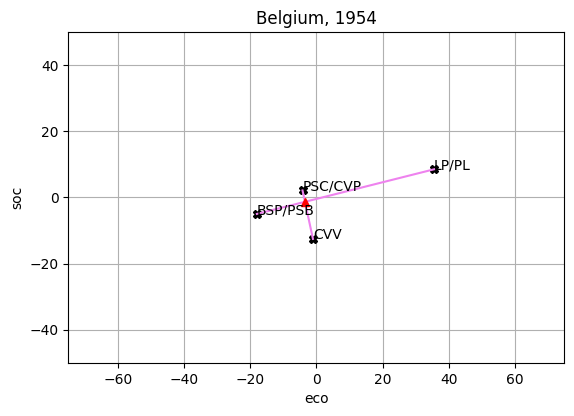

43


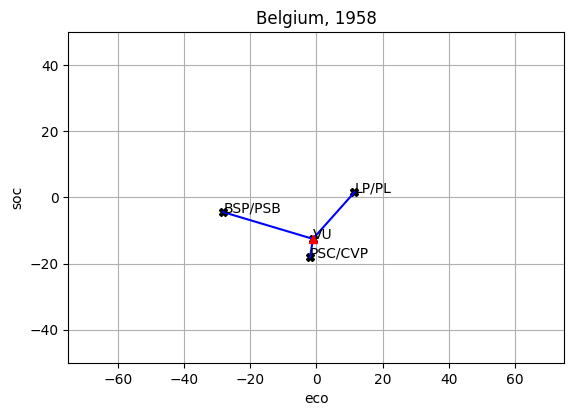

44


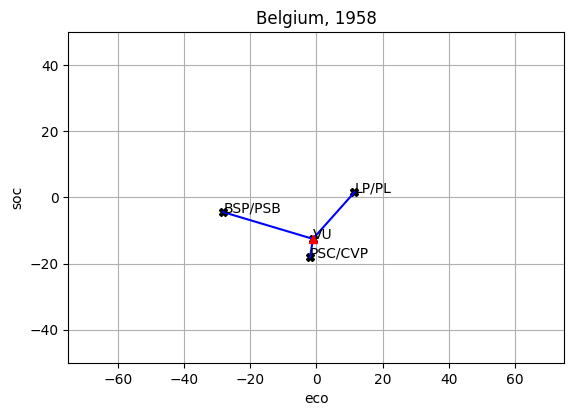

45


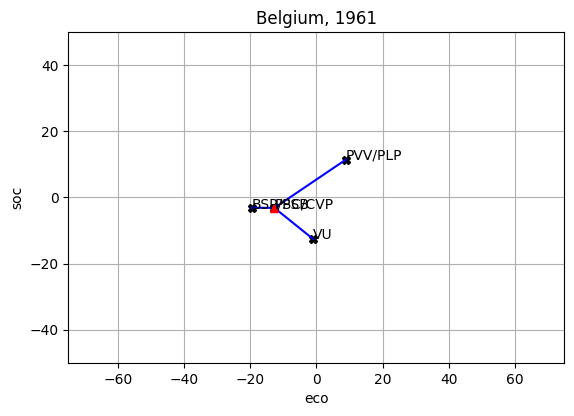

46


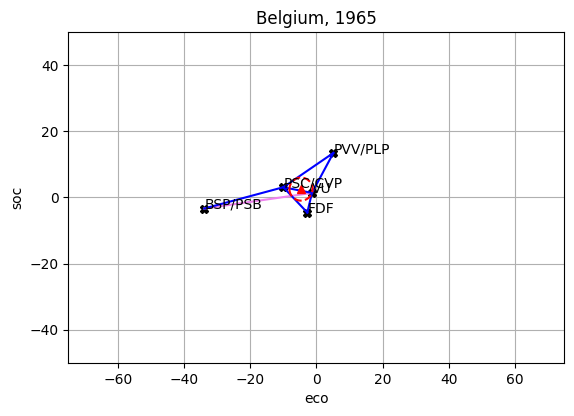

47


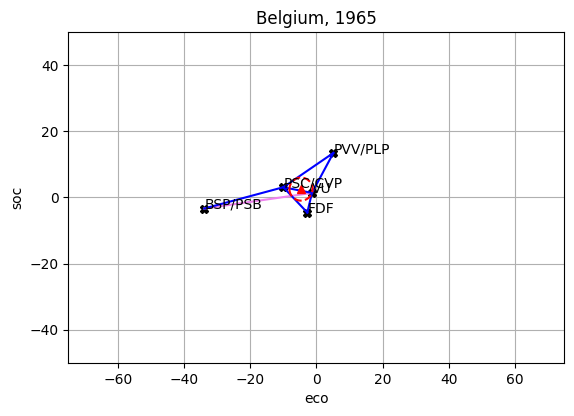

48


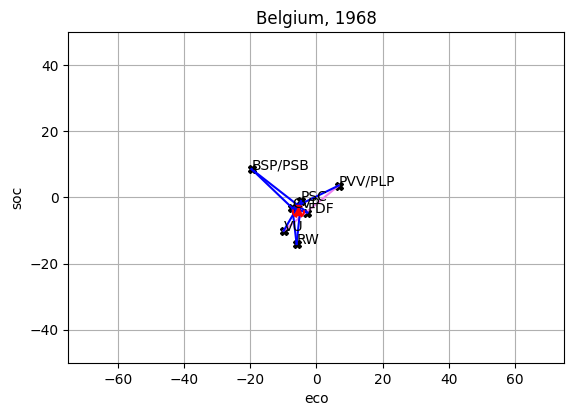

49


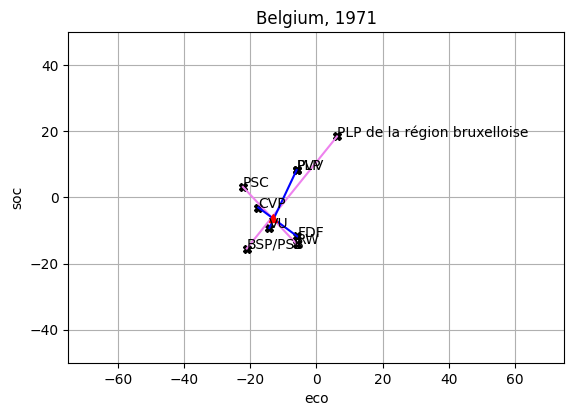

50


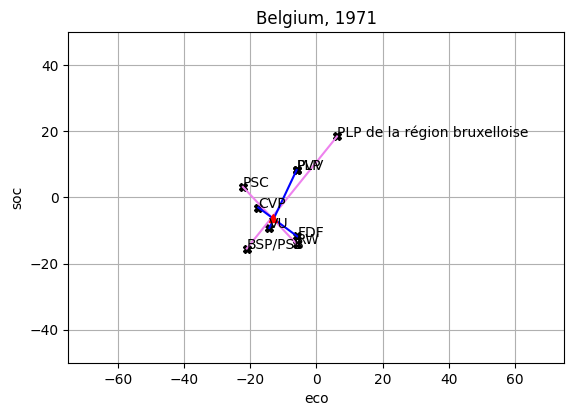

51


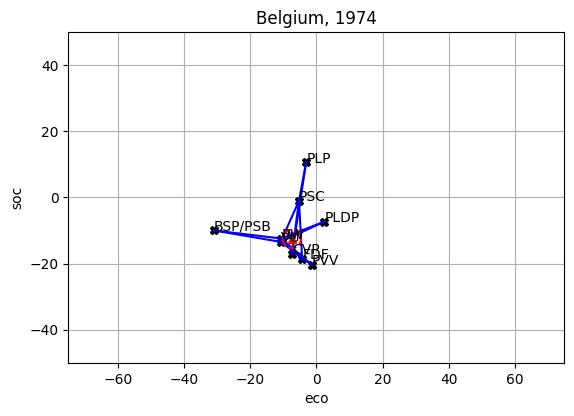

52


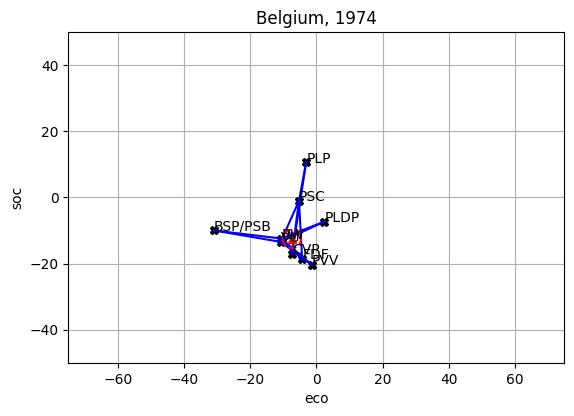

53


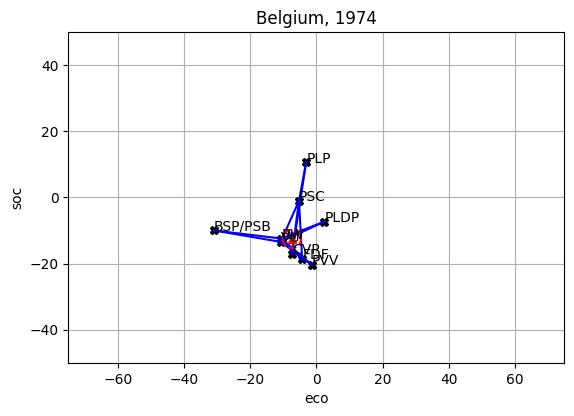

54


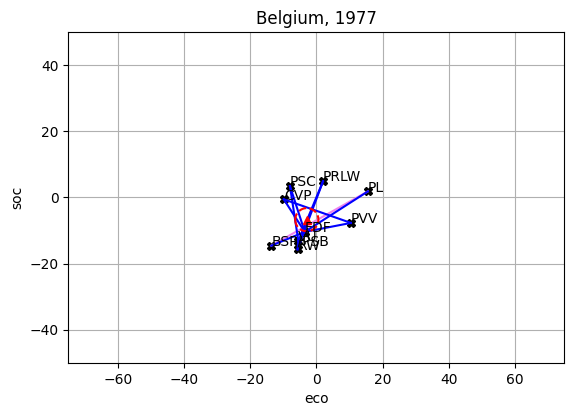

55


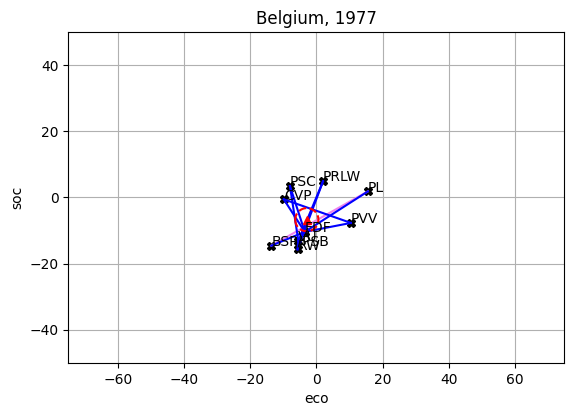

56


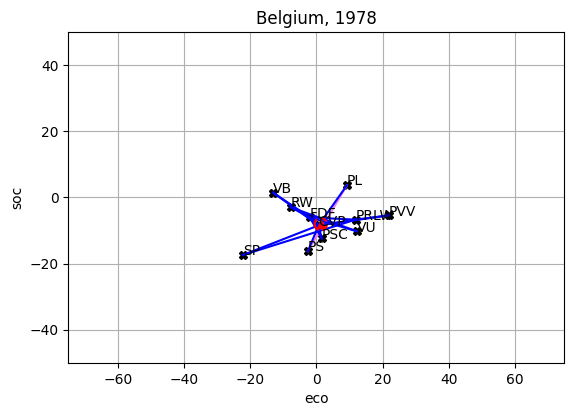

57


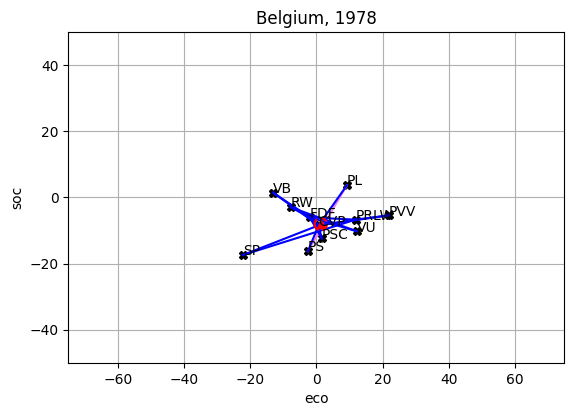

58


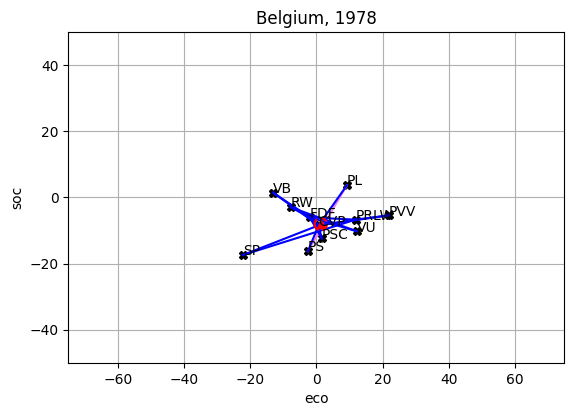

59


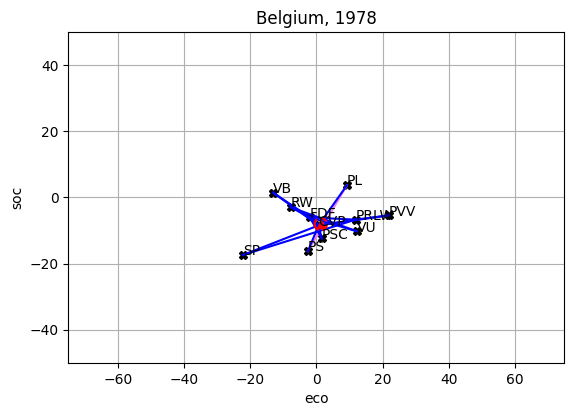

60


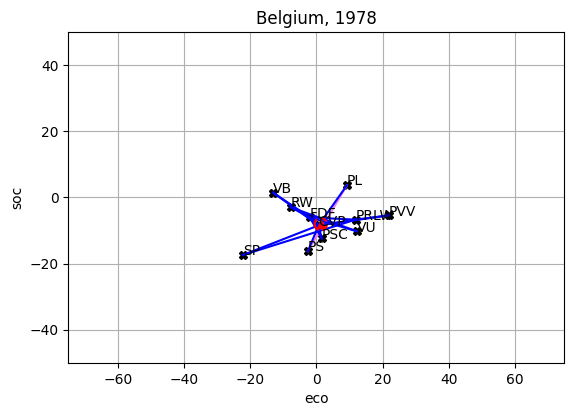

61


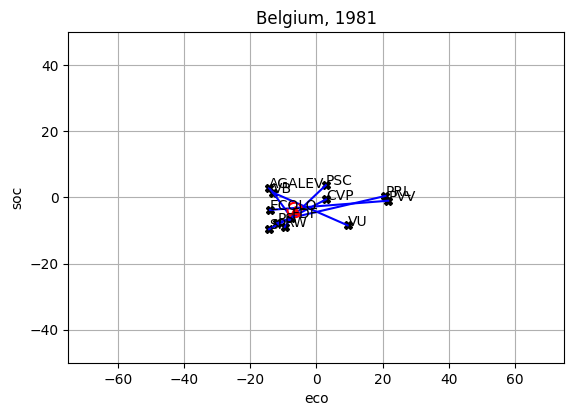

62


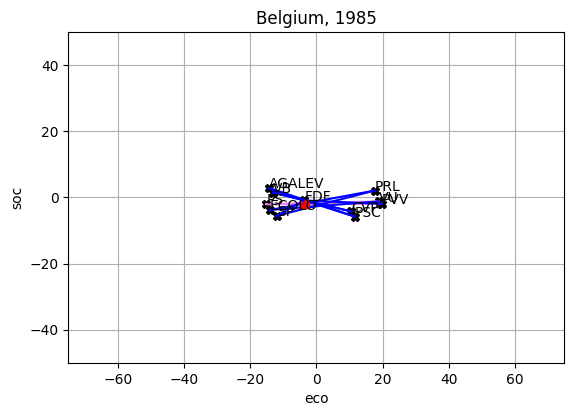

63


ValueError: not enough values to unpack (expected 2, got 0)

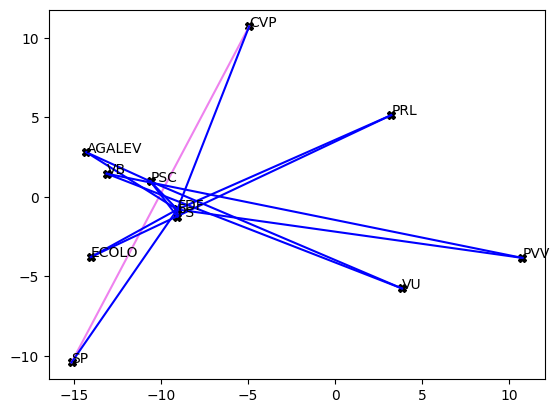

In [230]:
for k in new_parliament_bib.keys():
    print(k)
    parliament = new_parliament_bib[k]

    eco = parliament["member"]["stance_eco"]
    soc = parliament["member"]["stance_soc"]

    points = [(e,s) for e,s in zip(eco,soc)]
    yolk_center, yolk_radius = calculate_yolk(points, accuracy=0.001)

    plot = True
    colorblind = False
    if plot:
        if colorblind:
            median_color = "black"
            segment_color = "black"
            yolk_color = "black"
        else:
            median_color = "blue"
            segment_color = "violet"
            yolk_color = "red"

        points = list(dict.fromkeys(points)) # delete duplicate points
        median_segments = get_median_lines(points)
        median_lines = get_median_lines(points, only_in_bounds=False)
        median_lines = [ml for ml in median_lines if ml not in median_segments]

        fig, ax = plt.subplots()

        for n, (e, s) in enumerate(zip(eco, soc)):
            ax.plot(e, s, "X", color="black")
            ax.annotate(parliament["member"]["name"][n], (e,s))

        for n, m in enumerate(median_segments):
            x, y = transform_points(*m)
            if n == len(median_lines)-1:
                ax.plot(x, y, color=segment_color, label="Median Lines")
            else:
                ax.plot(x, y, color=segment_color)
        
        for n, m in enumerate(median_lines):
            x, y = transform_points(*m)
            if n == len(median_lines)-1:
                ax.plot(x, y, color=median_color, label="Median Lines")
            else:
                ax.plot(x, y, color=median_color)

        if yolk_radius != 0:
            x, y = circle(yolk_center, yolk_radius)
            ax.plot(x,y, label="Yolk", color=yolk_color, linestyle="dashed")

        if len(yolk_center) != 0:
            ax.plot(yolk_center[0], yolk_center[1], "^", color=yolk_color, label="Yolk Center")

    ax.set_xlabel("eco")
    ax.set_ylabel("soc")
    ax.set_xlim(-75,75)
    ax.set_ylim(-50,50)
    ax.set_title(f"{parliament["country"]}, {parliament["election_date"].year}")
    ax.grid()
    ax.set_aspect("equal")
    plt.show()

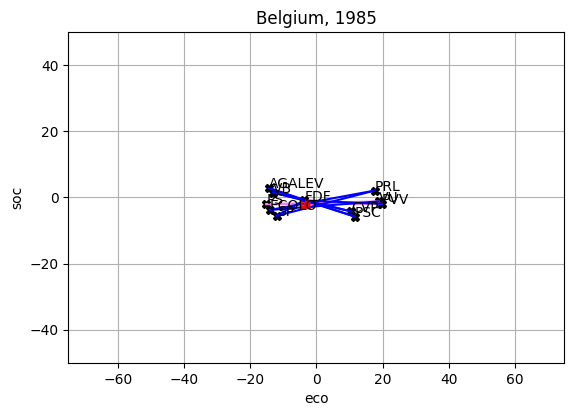

In [ ]:
parliament = new_parliament_bib[62]

eco = parliament["member"]["stance_eco"]
soc = parliament["member"]["stance_soc"]

points = [(e,s) for e,s in zip(eco,soc)]
yolk_center, yolk_radius = calculate_yolk(points, accuracy=0.1)
#yolk_center, yolk_radius = [], 0

plot = True
colorblind = False
if plot:
    if colorblind:
        median_color = "black"
        segment_color = "black"
        yolk_color = "black"
    else:
        median_color = "blue"
        segment_color = "violet"
        yolk_color = "red"

    points = list(dict.fromkeys(points)) # delete duplicate points 
    median_segments = get_median_lines(points)
    median_lines = get_median_lines(points, only_in_bounds=False)
    median_lines = [ml for ml in median_lines if ml not in median_segments]

    fig, ax = plt.subplots()

    for n, (e, s) in enumerate(zip(eco, soc)):
        ax.plot(e, s, "X", color="black")
        ax.annotate(parliament["member"]["name"][n], (e,s))

    for n, m in enumerate(median_segments):
        x, y = transform_points(*m)
        if n == len(median_lines)-1:
            ax.plot(x, y, color=segment_color, label="Median Lines")
        else:
            ax.plot(x, y, color=segment_color)
    
    for n, m in enumerate(median_lines):
        x, y = transform_points(*m)
        if n == len(median_lines)-1:
            ax.plot(x, y, color=median_color, label="Median Lines")
        else:
            ax.plot(x, y, color=median_color)

    if yolk_radius != 0:
        x, y = circle(yolk_center, yolk_radius)
        ax.plot(x,y, label="Yolk", color=yolk_color, linestyle="dashed")

    if len(yolk_center) != 0:
        ax.plot(yolk_center[0], yolk_center[1], "^", color=yolk_color, label="Yolk Center")

ax.set_xlabel("eco")
ax.set_ylabel("soc")
ax.set_xlim(-75,75)
ax.set_ylim(-50,50)
ax.set_title(f"{parliament["country"]}, {parliament["election_date"].year}")
ax.grid()
ax.set_aspect("equal")
plt.show()

In [240]:
ConvexHull(points).vertices

array([1, 3, 0, 2, 7, 4, 5], dtype=int32)